# Customer Segmentation Using KMeans

This notebook applies unsupervised learning techniques to segment customers
based on RFM features.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [8]:
df = pd.read_excel("Online Retail.xlsx")

df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]



In [9]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]


In [10]:
rfm_log = rfm.copy()
rfm_log[["Recency", "Frequency", "Monetary"]] = np.log1p(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)


Log transformation and scaling were applied to prepare the data
for distance-based clustering algorithms.


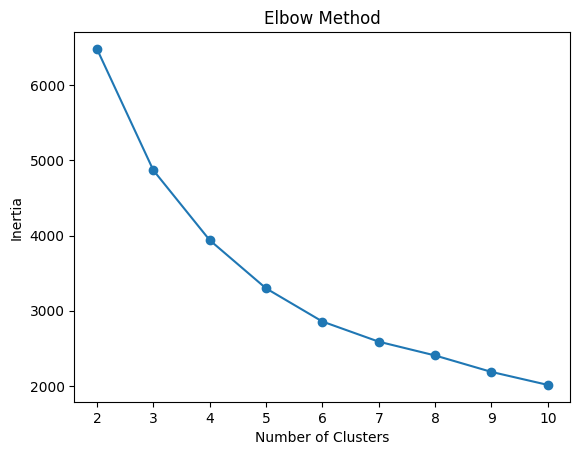

In [11]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


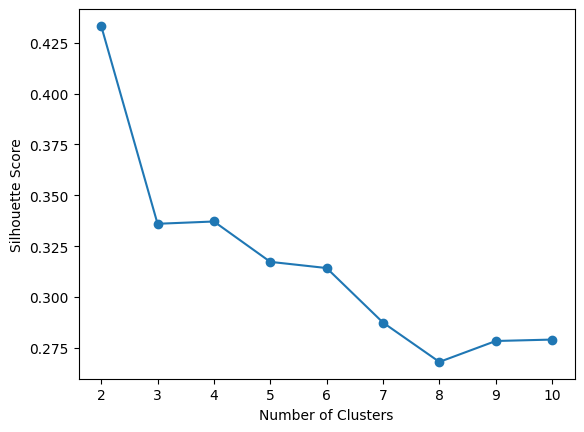

In [12]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()


The optimal number of clusters was selected by jointly analyzing
the Elbow Method and Silhouette Score.


In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [14]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "CustomerCount"})

cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,18.124253,2.148148,551.819534,837
1,12.131285,13.713687,8074.266872,716
2,71.084399,4.083546,1802.829005,1173
3,182.496898,1.318238,343.450032,1612


## Conclusion

Customers were successfully segmented based on purchasing behavior.
The resulting clusters reveal distinct patterns in recency, frequency,
and monetary value, which can support targeted marketing strategies.
